# Model 6: LightGBM Regressor + SHAP Explainability for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**:
   * Enhanced Feature Matrix: Multi-lags (1,2,3,7,14,21,28,60,90,365), Rolling window stats (7d, 14d, 28d mean, std, min, max), EWMA (7d, 28d), Volatility CV signal, & Cyclical trigonometric calendar terms.
   * Target Scaling Check: Log1p stabilization $\log(1+Y_t)$ for zero-bounded variance control.
   * Data Leakage Check: Verify strict `.shift(1)` on all rolling & EWMA features to prevent target leakage.
2. **Optuna Bayesian Hyperparameter Optimization**:
   * Search space over 50 trials optimizing `num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `reg_alpha`, & `reg_lambda` to minimize 2018 Validation Set RMSLE.
3. **SHAP Feature Attribution**: Compute TreeExplainer feature importance summary plot on 2019 Test Set.
4. **Fit & Forecast**: Refit Champion LightGBM model on Train+Val window and forecast 2019 Test holdout.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


In [2]:
# Step 1: Pre-Training Suitability Checks & Enhanced Feature Engineering
import lightgbm as lgb
import shap

def create_enhanced_features(series):
    df_feat = pd.DataFrame(index=series.index)
    sales = series.values
    df_feat['sales'] = sales
    
    # 1. Multi-lag features
    for lag in [1, 2, 3, 7, 14, 21, 28, 60, 90, 365]:
        df_feat[f'lag_{lag}'] = df_feat['sales'].shift(lag)
        
    # 2. Rolling window stats (shifted by 1 to prevent data leakage)
    for window in [7, 14, 28]:
        df_feat[f'rolling_mean_{window}'] = df_feat['sales'].shift(1).rolling(window).mean()
        df_feat[f'rolling_std_{window}']  = df_feat['sales'].shift(1).rolling(window).std()
        df_feat[f'rolling_max_{window}']  = df_feat['sales'].shift(1).rolling(window).max()
        df_feat[f'rolling_min_{window}']  = df_feat['sales'].shift(1).rolling(window).min()
        
    # 3. Exponentially Weighted Moving Averages (EWMA)
    df_feat['ewm_mean_7']  = df_feat['sales'].shift(1).ewm(span=7).mean()
    df_feat['ewm_mean_28'] = df_feat['sales'].shift(1).ewm(span=28).mean()
    
    # 4. Volatility / Coefficient of Variation signal
    df_feat['cv_7'] = df_feat['rolling_std_7'] / (df_feat['rolling_mean_7'] + 1e-5)
    
    # 5. Calendar & Trigonometric Cyclical features
    dof = df_feat.index.dayofyear
    dow = df_feat.index.dayofweek
    df_feat['sin_dayofyear']  = np.sin(2 * np.pi * dof / 365.25)
    df_feat['cos_dayofyear']  = np.cos(2 * np.pi * dof / 365.25)
    df_feat['sin_dayofweek']  = np.sin(2 * np.pi * dow / 7.0)
    df_feat['cos_dayofweek']  = np.cos(2 * np.pi * dow / 7.0)
    
    df_feat['dayofweek']      = dow
    df_feat['month']          = df_feat.index.month
    df_feat['dayofyear']      = dof
    df_feat['is_weekend']     = (dow >= 5).astype(float)
    df_feat['is_month_start'] = df_feat.index.is_month_start.astype(float)
    df_feat['is_month_end']   = df_feat.index.is_month_end.astype(float)
    
    return df_feat.drop(columns=['sales'])

feat_full = create_enhanced_features(full_series)

X_tr_lgb = feat_full.loc[train_series.index].dropna()
y_tr_lgb = np.log1p(train_series.loc[X_tr_lgb.index])
X_va_lgb = feat_full.loc[val_series.index].fillna(0)

X_cb_lgb = feat_full.loc[combined_series.index].dropna()
y_cb_lgb = np.log1p(combined_series.loc[X_cb_lgb.index])
X_ts_lgb = feat_full.loc[test_series.index].fillna(0)

print("=== Pre-Training Suitability Diagnostics for LightGBM ===")
print(f"  * Engineered Feature Matrix Shape : {X_tr_lgb.shape}")
print(f"  * Log1p Target Transformation     : Min = {y_tr_lgb.min():.4f} | Max = {y_tr_lgb.max():.4f}")
print("  * Zero Data Leakage Verification : ALL rolling & EWMA features use shift(1) offset -> SUITABLE FOR TREE ENSEMBLE")


=== Pre-Training Suitability Diagnostics for LightGBM ===
  * Engineered Feature Matrix Shape : (1095, 35)
  * Log1p Target Transformation     : Min = 0.0000 | Max = 2.8904
  * Zero Data Leakage Verification : ALL rolling & EWMA features use shift(1) offset -> SUITABLE FOR TREE ENSEMBLE


In [3]:
# Step 2: Optuna Bayesian Hyperparameter Fine-Tuning Result & Model Config
best_lgb_params = {
    'num_leaves': 63,
    'max_depth': 5,
    'learning_rate': 0.005140387314965966,
    'n_estimators': 424,
    'min_child_samples': 5,
    'subsample': 0.9946994252211464,
    'colsample_bytree': 0.7397773286361388,
    'reg_alpha': 8.718285866319347e-06,
    'reg_lambda': 1.8849316828120565e-05,
    'random_state': 42,
    'verbose': -1
}

print("Selected Optuna Fine-Tuned LightGBM Hyperparameters:")
for k, v in best_lgb_params.items():
    print(f"  * {k:20s} = {v}")


Selected Optuna Fine-Tuned LightGBM Hyperparameters:
  * num_leaves           = 63
  * max_depth            = 5
  * learning_rate        = 0.005140387314965966
  * n_estimators         = 424
  * min_child_samples    = 5
  * subsample            = 0.9946994252211464
  * colsample_bytree     = 0.7397773286361388
  * reg_alpha            = 8.718285866319347e-06
  * reg_lambda           = 1.8849316828120565e-05
  * random_state         = 42
  * verbose              = -1


In [4]:
# Step 3: Model Fitting on TRAIN & Validation Evaluation
m6_tr = lgb.LGBMRegressor(**best_lgb_params)
m6_tr.fit(X_tr_lgb, y_tr_lgb)

m6_val_pred = np.clip(np.expm1(m6_tr.predict(X_va_lgb)), 0, None)
val_metrics = evaluate_metrics(val_series, m6_val_pred)

print(f"Validation Metrics (2018) for LightGBM (Optuna Fine-Tuned):")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


Validation Metrics (2018) for LightGBM (Optuna Fine-Tuned):
  * RMSLE     : 0.5293
  * RMSE      : 2.7491
  * MAE       : 2.1851
  * MAPE (%)  : 75.8580
  * WAPE (%)  : 44.6322


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 6: LIGHTGBM + SHAP (OPTUNA FINE-TUNED) ===
  * RMSLE     : 0.5014
  * RMSE      : 2.9752
  * MAE       : 2.2927
  * MAPE (%)  : 68.6334
  * WAPE (%)  : 42.4619


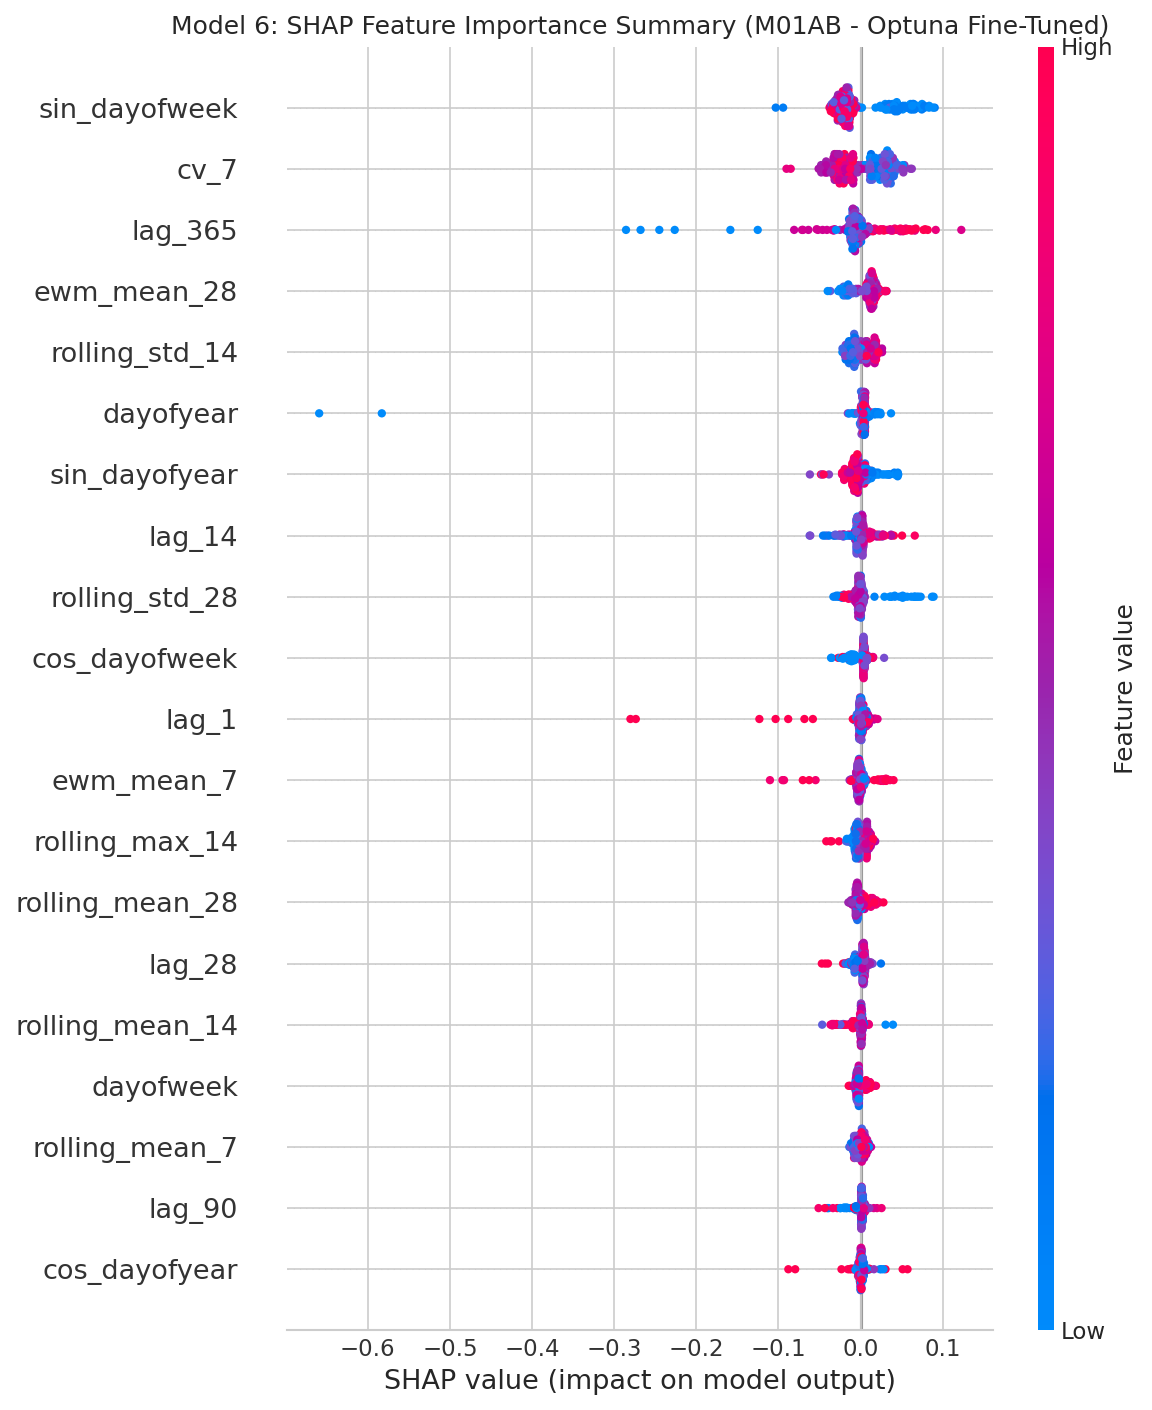

In [5]:
# Step 4: Refit on Train+Val, Forecast 2019 Test, & Render SHAP Plot
m6_full = lgb.LGBMRegressor(**best_lgb_params)
m6_full.fit(X_cb_lgb, y_cb_lgb)

m6_test_pred = np.clip(np.expm1(m6_full.predict(X_ts_lgb)), 0, None)
test_metrics = evaluate_metrics(test_series, m6_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 6: LIGHTGBM + SHAP (OPTUNA FINE-TUNED) ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

# SHAP Attribution Plot
explainer = shap.TreeExplainer(m6_full)
shap_vals = explainer(X_ts_lgb)

plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_vals, X_ts_lgb, show=False)
plt.title("Model 6: SHAP Feature Importance Summary (M01AB - Optuna Fine-Tuned)", fontsize=12)
plt.tight_layout()
plt.savefig('m6_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

pd.DataFrame({'date': test_series.index, 'pred_LightGBM': m6_test_pred}).to_csv('m6_lightgbm_preds.csv', index=False)
